# 02 — Exploratory Data Analysis (EDA)
**Gurugram Air Quality Study (2020–2024)**

Produces paper-quality figures:
- Correlation heatmaps (4 matrices)
- PM2.5 seasonal boxplot
- AQI distribution
- Time-series plot
- Satellite vs Ground scatter plots

**Requires:** Run `01_data_preprocessing.ipynb` first.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

BASE = os.getcwd()
OUT  = os.path.join(BASE, "outputs")
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(os.path.join(OUT, "merged_clean.csv"), parse_dates=["date"])
print(f"Loaded: {df.shape}")
df.head()

Loaded: (1768, 32)


,date,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,O3,month,day_of_year,year,season,season_enc,PM2.5_lag1,PM2.5_lag7,AQI_category,AQI_label
0,2020-01-01,305.93,NaN,201.53,53.10,203.70,NaN,17.60,3.98,24.78,...,0.160842,1,1,2020,Winter,0,NaN,NaN,Severe,4.0
1,2020-01-02,71.69,NaN,67.04,52.42,78.21,NaN,8.70,2.01,47.42,...,0.161014,1,2,2020,Winter,0,305.93,NaN,Poor,2.0
2,2020-01-03,25.41,NaN,23.90,38.65,37.23,NaN,3.36,1.17,69.87,...,0.142446,1,3,2020,Winter,0,71.69,NaN,Good,0.0
3,2020-01-04,26.19,NaN,7.73,20.61,16.92,NaN,8.00,0.48,61.52,...,0.134150,1,4,2020,Winter,0,25.41,NaN,Good,0.0
4,2020-01-05,53.15,NaN,3.63,26.53,15.18,NaN,2.62,1.17,111.71,...,0.125270,1,5,2020,Winter,0,26.19,NaN,Moderate,1.0


## 1. Correlation Heatmap — CPCB Pollutants

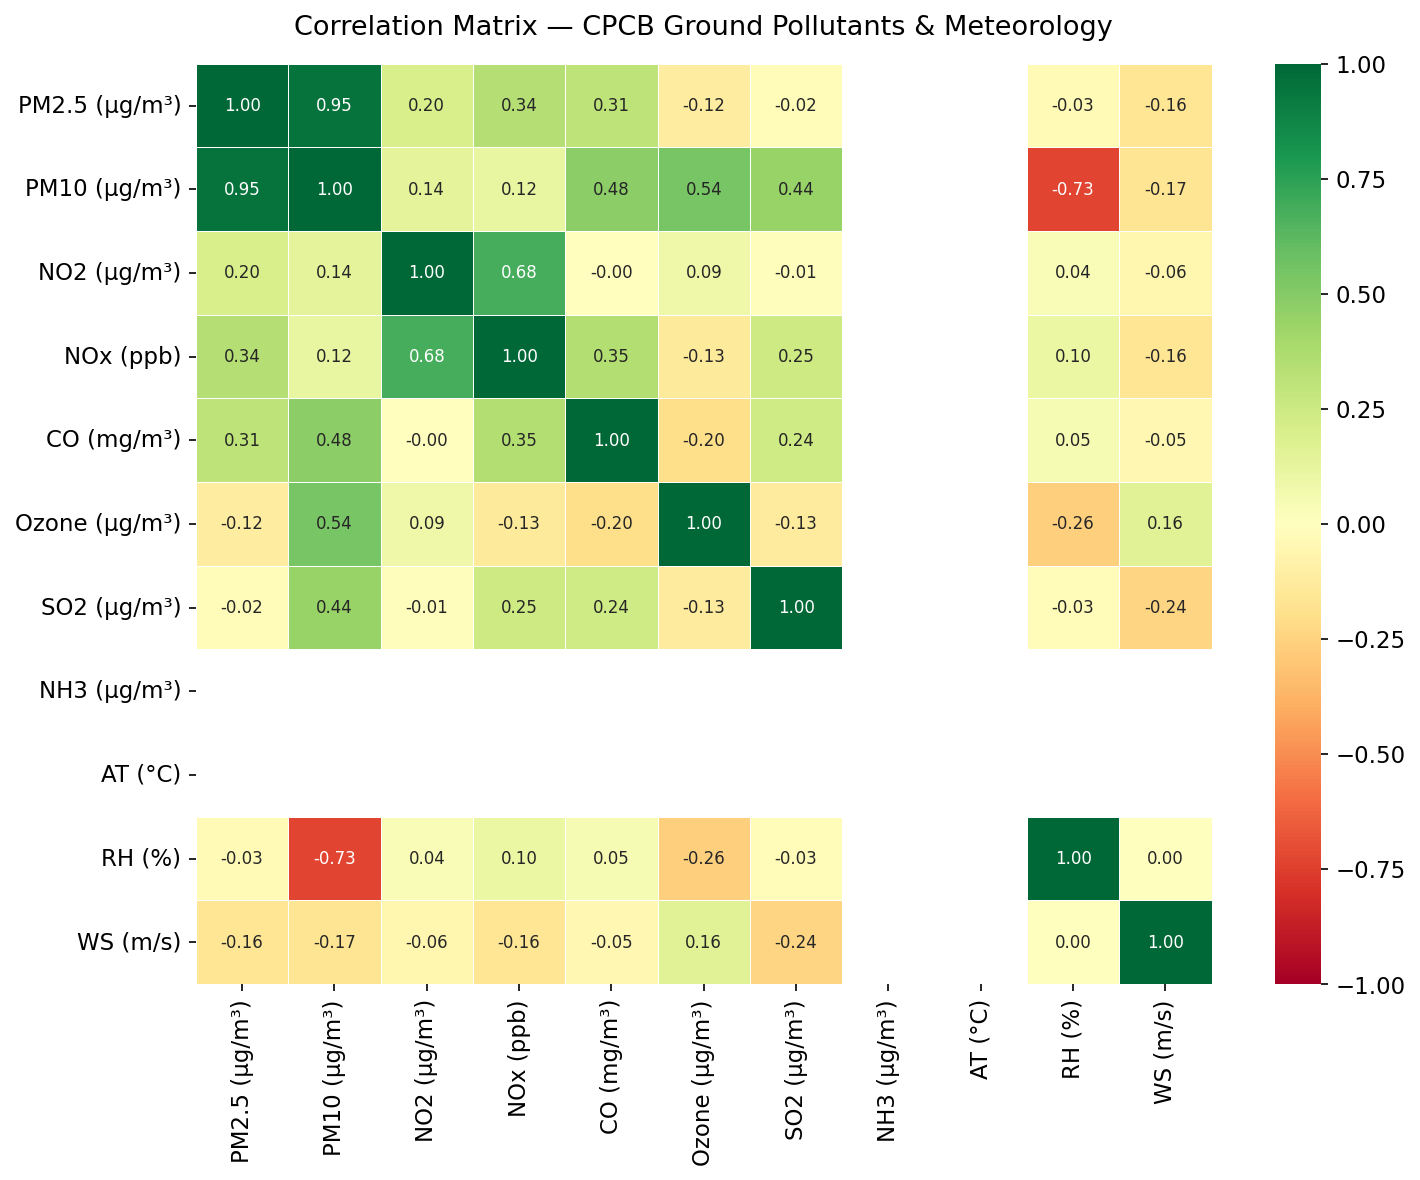

In [2]:
cpcb_vars = [
    "PM2.5 (µg/m³)", "PM10 (µg/m³)", "NO2 (µg/m³)", "NOx (ppb)",
    "CO (mg/m³)", "Ozone (µg/m³)", "SO2 (µg/m³)", "NH3 (µg/m³)",
    "AT (°C)", "RH (%)", "WS (m/s)",
]
cpcb_vars = [c for c in cpcb_vars if c in df.columns]
corr_cpcb = df[cpcb_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_cpcb, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1, linewidths=0.4,
    annot_kws={"size": 8}, ax=ax
)
ax.set_title("Correlation Matrix — CPCB Ground Pollutants & Meteorology", pad=14)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "corr_cpcb.png"))
plt.show()

## 2. Correlation Heatmap — Sentinel-5P Gases

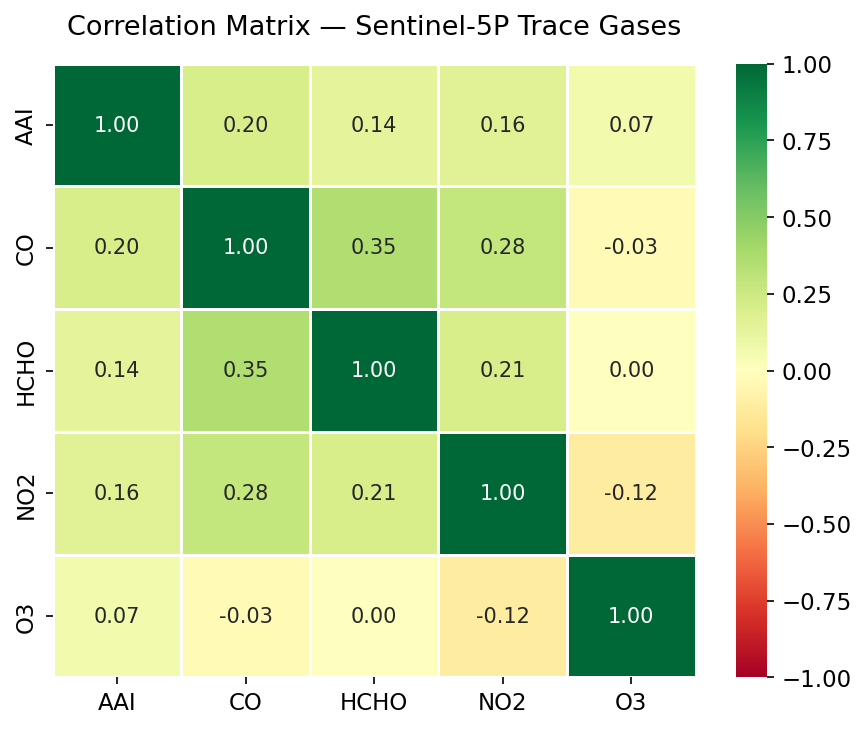

In [3]:
sent_vars = ["AAI", "CO", "HCHO", "NO2", "O3"]
sent_vars = [c for c in sent_vars if c in df.columns]
corr_sent = df[sent_vars].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr_sent, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={"size": 10}, ax=ax
)
ax.set_title("Correlation Matrix — Sentinel-5P Trace Gases", pad=14)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "corr_sentinel.png"))
plt.show()

## 3. Correlation Heatmap — LST vs CPCB

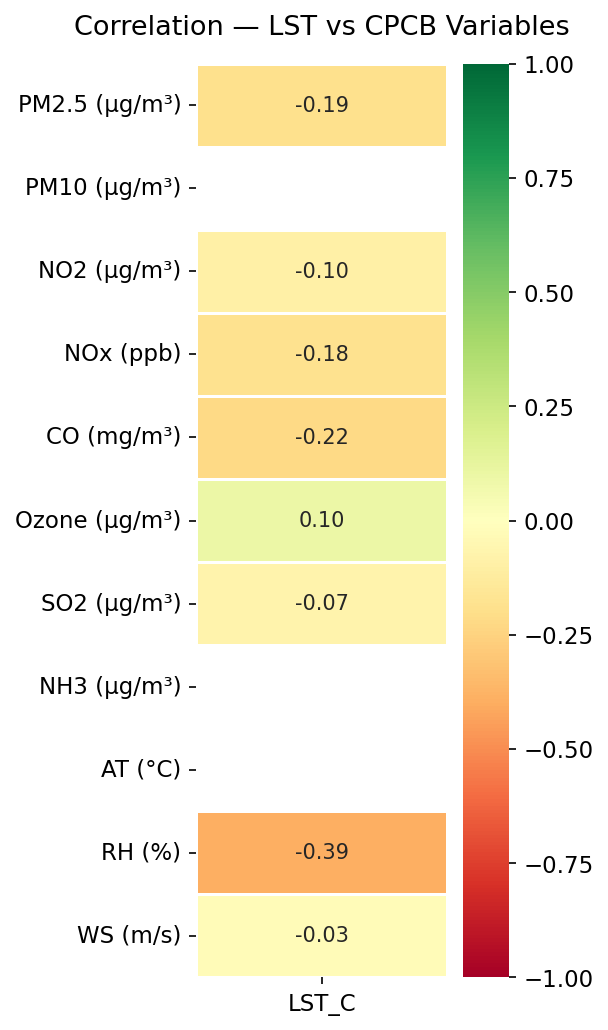

In [4]:
lst_cpcb_vars = ["LST_C"] + [c for c in cpcb_vars if c in df.columns]
lst_cpcb_vars = [c for c in lst_cpcb_vars if c in df.columns]
corr_lst_cpcb = df[lst_cpcb_vars].corr()[["LST_C"]].drop("LST_C")

fig, ax = plt.subplots(figsize=(4, 7))
sns.heatmap(
    corr_lst_cpcb, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={"size": 10}, ax=ax
)
ax.set_title("Correlation — LST vs CPCB Variables", pad=14)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "corr_lst_cpcb.png"))
plt.show()

## 4. Correlation Heatmap — LST vs Sentinel-5P

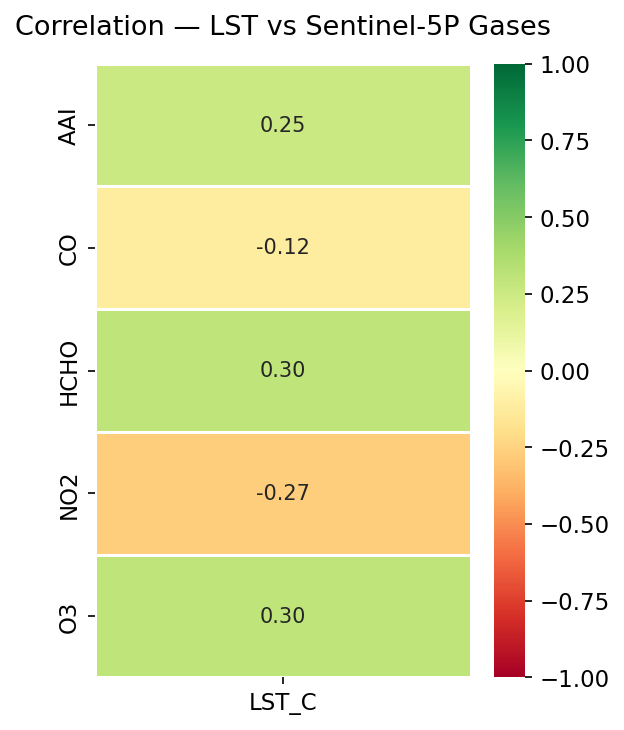

In [5]:
lst_sent_vars = ["LST_C"] + sent_vars
lst_sent_vars = [c for c in lst_sent_vars if c in df.columns]
corr_lst_sent = df[lst_sent_vars].corr()[["LST_C"]].drop("LST_C")

fig, ax = plt.subplots(figsize=(4, 5))
sns.heatmap(
    corr_lst_sent, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={"size": 10}, ax=ax
)
ax.set_title("Correlation — LST vs Sentinel-5P Gases", pad=14)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "corr_lst_sentinel.png"))
plt.show()

## 5. PM2.5 Seasonal Boxplot

C:\Users\Jain\AppData\Local\Temp\ipykernel_10968\896959103.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


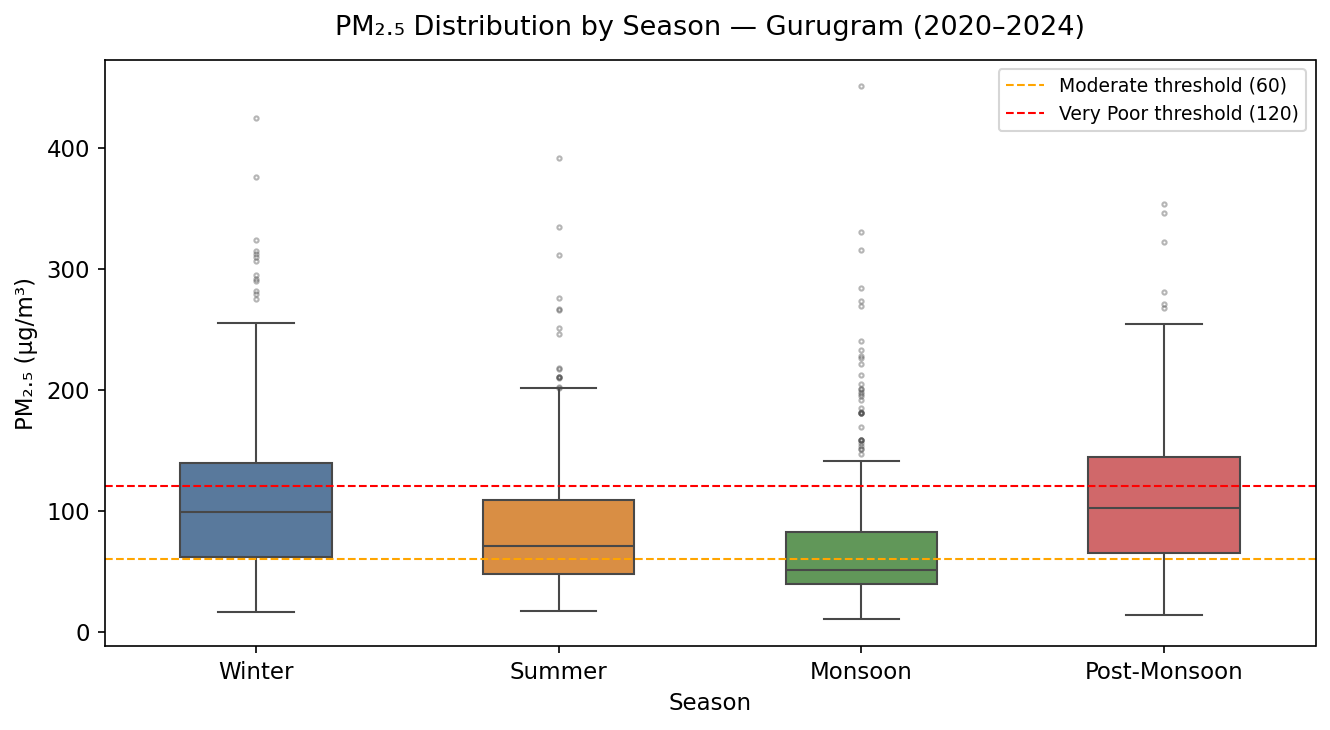

In [6]:
season_order = ["Winter", "Summer", "Monsoon", "Post-Monsoon"]
palette = {"Winter": "#4e79a7", "Summer": "#f28e2b", "Monsoon": "#59a14f", "Post-Monsoon": "#e15759"}

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df, x="season", y="PM2.5 (µg/m³)",
    order=season_order, palette=palette,
    width=0.5, flierprops=dict(marker="o", markersize=2, alpha=0.4), ax=ax
)
ax.set_title("PM\u2082.\u2085 Distribution by Season — Gurugram (2020–2024)", pad=12)
ax.set_xlabel("Season")
ax.set_ylabel("PM\u2082.\u2085 (µg/m³)")
ax.axhline(60, color="orange", ls="--", lw=1, label="Moderate threshold (60)")
ax.axhline(120, color="red", ls="--", lw=1, label="Very Poor threshold (120)")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "pm25_seasonal_boxplot.png"))
plt.show()

## 6. AQI Category Distribution

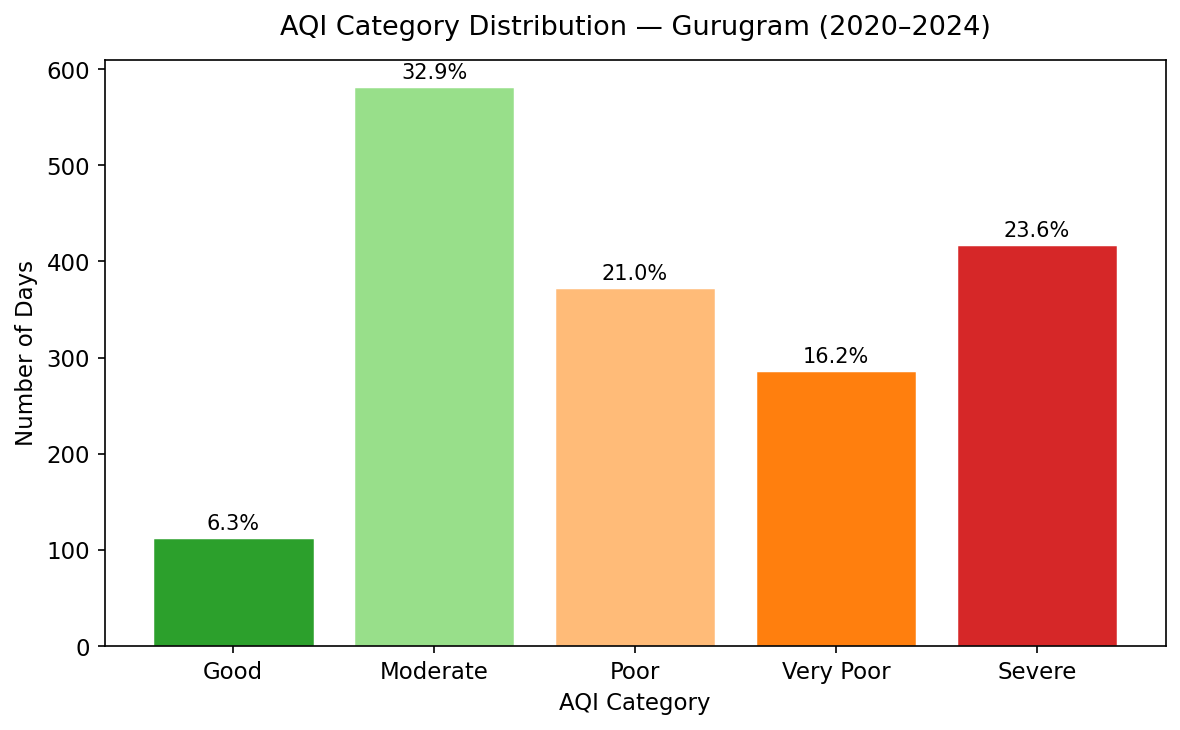

In [7]:
aqi_order  = ["Good", "Moderate", "Poor", "Very Poor", "Severe"]
aqi_colors = ["#2ca02c", "#98df8a", "#ffbb78", "#ff7f0e", "#d62728"]

counts = df["AQI_category"].value_counts().reindex(aqi_order, fill_value=0)
pct    = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(aqi_order, counts.values, color=aqi_colors, edgecolor="white", linewidth=0.7)
for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{p:.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_title("AQI Category Distribution — Gurugram (2020–2024)", pad=12)
ax.set_xlabel("AQI Category")
ax.set_ylabel("Number of Days")
plt.tight_layout()
fig.savefig(os.path.join(OUT, "aqi_distribution.png"))
plt.show()

## 7. PM2.5 Time-Series (2020–2024)

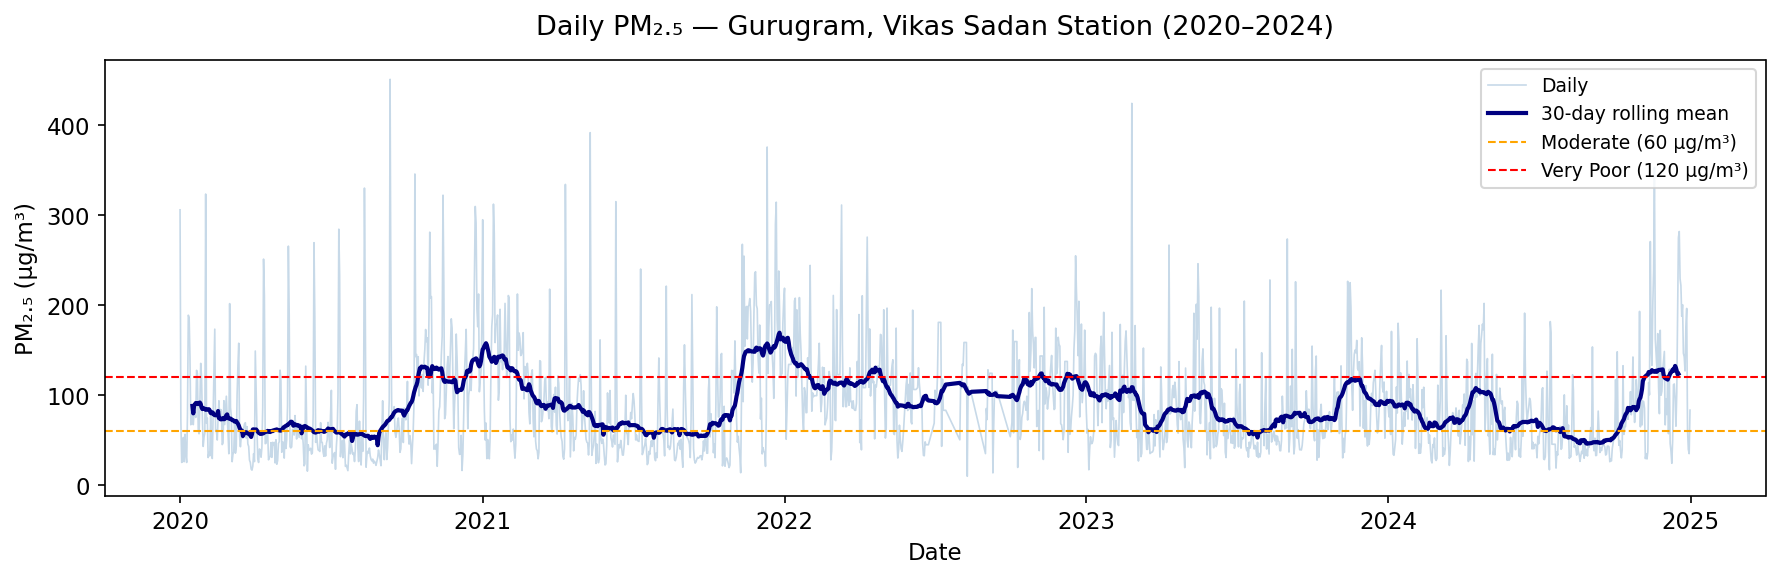

In [8]:
rolling = df.set_index("date")["PM2.5 (µg/m³)"].rolling(30, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["PM2.5 (µg/m³)"], color="steelblue", alpha=0.3, lw=0.8, label="Daily")
ax.plot(rolling.index, rolling.values, color="navy", lw=2, label="30-day rolling mean")
ax.axhline(60,  color="orange", ls="--", lw=1, label="Moderate (60 µg/m³)")
ax.axhline(120, color="red",    ls="--", lw=1, label="Very Poor (120 µg/m³)")
ax.set_title("Daily PM\u2082.\u2085 — Gurugram, Vikas Sadan Station (2020–2024)", pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("PM\u2082.\u2085 (µg/m³)")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
fig.savefig(os.path.join(OUT, "pm25_timeseries.png"))
plt.show()

## 8. Satellite NO₂ vs Ground NO₂

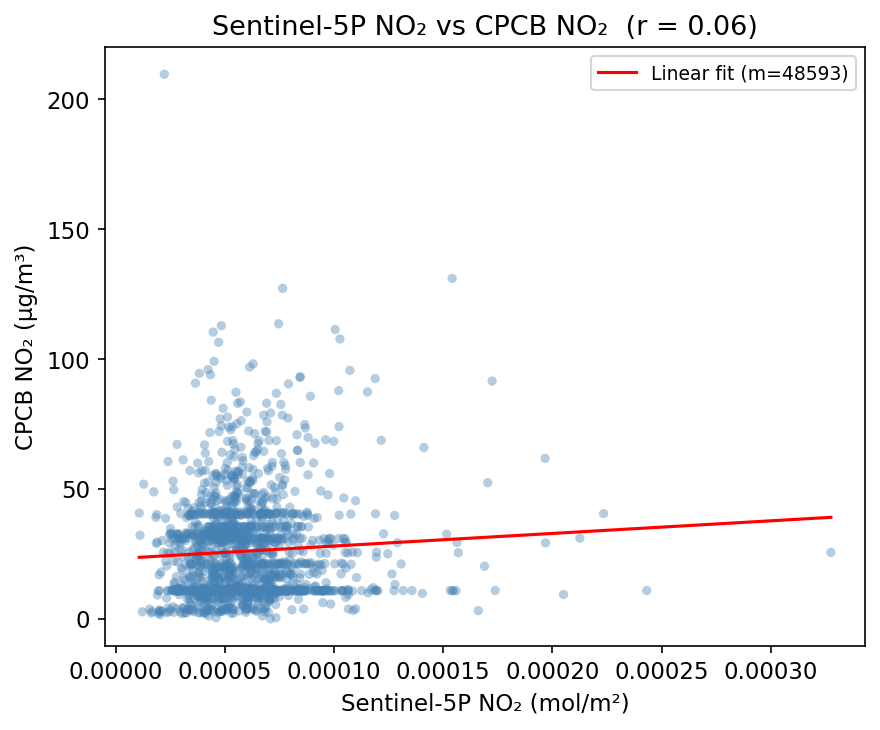

In [9]:
scatter_df = df[["NO2", "NO2 (µg/m³)"]].dropna()

if len(scatter_df) > 0:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(scatter_df["NO2"], scatter_df["NO2 (µg/m³)"],
               alpha=0.4, s=20, color="steelblue", edgecolors="none")

    # Fit line
    m, b = np.polyfit(scatter_df["NO2"], scatter_df["NO2 (µg/m³)"], 1)
    xr = np.linspace(scatter_df["NO2"].min(), scatter_df["NO2"].max(), 100)
    ax.plot(xr, m*xr + b, color="red", lw=1.5, label=f"Linear fit (m={m:.0f})") 
    corr_val = scatter_df.corr().iloc[0, 1]
    ax.set_title(f"Sentinel-5P NO₂ vs CPCB NO₂  (r = {corr_val:.2f})")
    ax.set_xlabel("Sentinel-5P NO₂ (mol/m²)")
    ax.set_ylabel("CPCB NO₂ (µg/m³)")
    ax.legend(fontsize=9)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT, "scatter_no2_sat_vs_ground.png"))
    plt.show()
else:
    print("No overlapping NO2 data available for scatter plot.")

## 9. LST vs PM2.5 Scatter

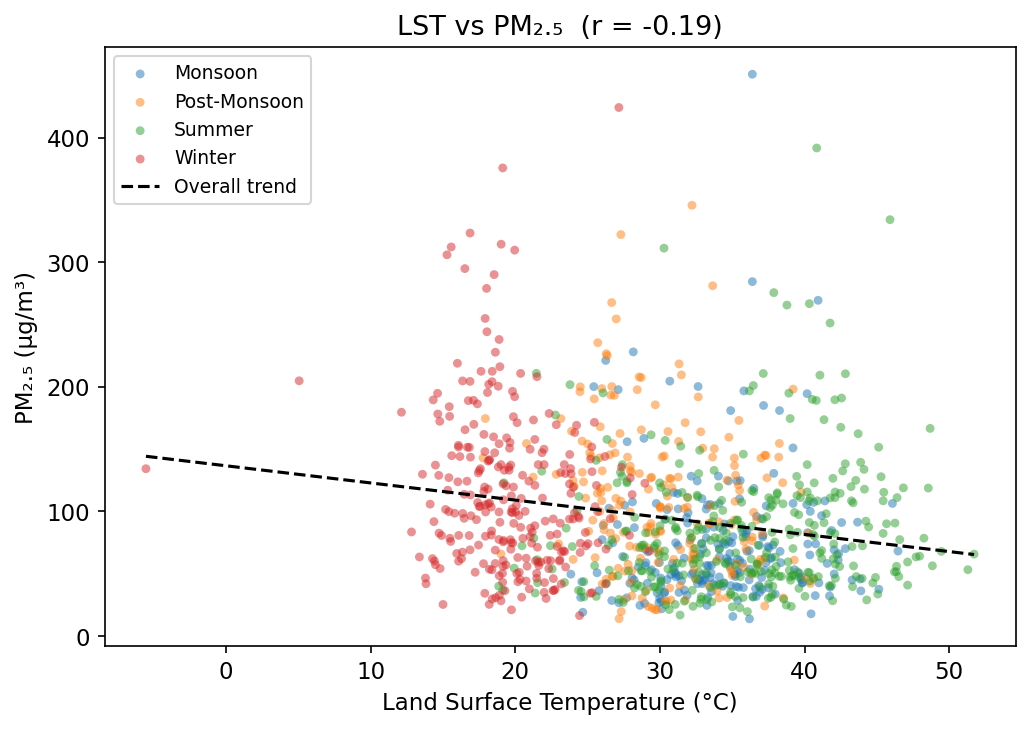

In [10]:
scatter2 = df[["LST_C", "PM2.5 (µg/m³)", "season"]].dropna()

fig, ax = plt.subplots(figsize=(7, 5))
for season, grp in scatter2.groupby("season"):
    ax.scatter(grp["LST_C"], grp["PM2.5 (µg/m³)"],
               alpha=0.5, s=18, label=season, edgecolors="none")

if len(scatter2) > 1:
    m, b = np.polyfit(scatter2["LST_C"], scatter2["PM2.5 (µg/m³)"], 1)
    xr = np.linspace(scatter2["LST_C"].min(), scatter2["LST_C"].max(), 100)
    ax.plot(xr, m*xr + b, "k--", lw=1.5, label="Overall trend")
    corr_val = scatter2[["LST_C", "PM2.5 (µg/m³)"]].corr().iloc[0, 1]
    ax.set_title(f"LST vs PM\u2082.\u2085  (r = {corr_val:.2f})")

ax.set_xlabel("Land Surface Temperature (°C)")
ax.set_ylabel("PM\u2082.\u2085 (µg/m³)")
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "scatter_lst_vs_pm25.png"))
plt.show()

## 10. Monthly Average PM2.5 Bar Chart

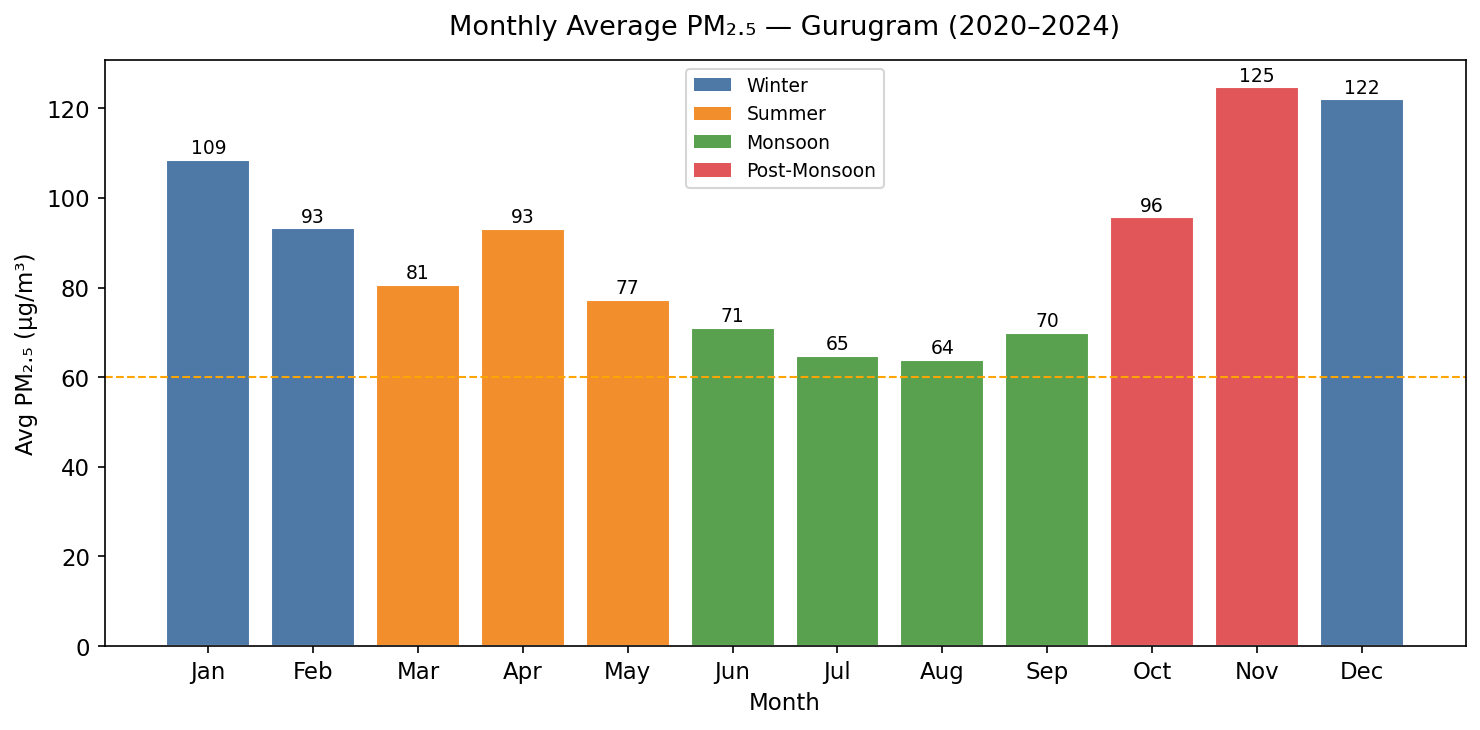

In [11]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby("month")["PM2.5 (µg/m³)"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#4e79a7" if m in [12,1,2] else
          "#f28e2b" if m in [3,4,5] else
          "#59a14f" if m in [6,7,8,9] else
          "#e15759" for m in monthly.index]
bars = ax.bar([month_names[m-1] for m in monthly.index], monthly.values, color=colors, edgecolor="white")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{bar.get_height():.0f}", ha="center", va="bottom", fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4e79a7", label="Winter"),
    Patch(facecolor="#f28e2b", label="Summer"),
    Patch(facecolor="#59a14f", label="Monsoon"),
    Patch(facecolor="#e15759", label="Post-Monsoon"),
]
ax.legend(handles=legend_elements, fontsize=9)
ax.set_title("Monthly Average PM\u2082.\u2085 — Gurugram (2020–2024)", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Avg PM\u2082.\u2085 (µg/m³)")
ax.axhline(60, color="orange", ls="--", lw=1)
plt.tight_layout()
fig.savefig(os.path.join(OUT, "monthly_avg_pm25.png"))
plt.show()